# Notebook 10 -- Walk-Forward Backtesting

> *Does the signal generate real profit after costs?*

**Setup:** XGB-Pruned model, 11 features (from NB09 pruning), SET Index target.
Walk-forward expanding window, 2003–2025.

| Section | Question |
|---|---|
| 1. PnL Curve | Cumulative return vs Buy-and-Hold |
| 2. Risk Metrics | Sharpe, Sortino, Max Drawdown, Win Rate |
| 3. TC Sensitivity | Does it survive 0.1% / 0.2% / 0.3% per trade? |
| 4. Annual Breakdown | Year-by-year performance |
| 5. Regime Analysis | Bull / Normal / Crisis PnL |
| 6. Verdict | Is this signal investable? |


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('../..')
PROC = ROOT / 'data' / 'processed'
FIGS = Path('figs')
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11,
})

print('Setup complete.')

Setup complete.


---
## Section 1 -- Data & Model Setup


In [2]:
clean = pd.read_csv(PROC / 'unified_weekly_clean.csv', index_col=0, parse_dates=True)
print(f'Dataset: {clean.shape[0]} rows x {clean.shape[1]} cols')

TARGET = 'SET_index_ret_w_fwd1'
df = clean.dropna(subset=[TARGET]).copy()

# 11 KEEP features from NB09 pruning decision
FEATURES = [
    'sp500_ret_w',          # US equity return (contemporaneous)
    'SET_index_rvol_4w',    # SET realized vol
    'sp500_rvol_4w',        # US equity realized vol
    'us_10yr_treasury_ret_w', # US 10yr bond return
    'oil_ret_d_lag1',       # Oil lag-1 daily
    'eem_ret_d_lag1',       # EM ETF lag-1 daily
    'gold_rvol_4w',         # Gold realized vol
    'us_2yr_treasury_ret_w', # US 2yr bond return
    'oil_ret_w',            # Oil weekly return
    'SET_index_ret_w',      # SET weekly return (momentum/reversal)
    'USD_THB_ret_w',        # USD/THB weekly return
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f'Features: {len(FEATURES)}')

# XGB-Pruned: best config from NB09 Task 3
MODEL = XGBRegressor(
    n_estimators=50, max_depth=2, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.5,
    min_child_weight=20, reg_alpha=1.0, reg_lambda=10.0,
    random_state=42, verbosity=0, n_jobs=1
)

MIN_TRAIN = 156  # 3 years
FOLD_SIZE  = 52  # 1 year
print(f'Walk-forward: min_train={MIN_TRAIN}w, fold={FOLD_SIZE}w')
print(f'First OOS date: {df.index[MIN_TRAIN].date()}')

Dataset: 1322 rows x 72 cols
Features: 11
Walk-forward: min_train=156w, fold=52w
First OOS date: 2003-08-29


In [3]:
# Walk-forward: collect weekly predictions + actual returns
data = df[FEATURES + [TARGET]].dropna(subset=[TARGET])
n = len(data)
t = MIN_TRAIN

records = []
while t + FOLD_SIZE <= n:
    train = data.iloc[:t]
    test  = data.iloc[t:t+FOLD_SIZE]
    medians = train[FEATURES].median()
    Xtr = train[FEATURES].fillna(medians).fillna(0.).values.astype(float)
    Xte = test[FEATURES].fillna(medians).fillna(0.).values.astype(float)
    ytr = train[TARGET].values
    yte = test[TARGET].values

    m = clone(MODEL)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)

    for date, y_true, y_pred in zip(test.index, yte, pred):
        records.append({
            'date':   date,
            'actual': y_true,
            'signal': np.sign(y_pred),
            'pred':   y_pred,
        })
    t += FOLD_SIZE

pnl = pd.DataFrame(records).set_index('date').sort_index()
pnl['gross_ret'] = pnl['signal'] * pnl['actual']  # long-short, no TC

print(f'OOS period: {pnl.index[0].date()} -> {pnl.index[-1].date()}')
print(f'OOS weeks:  {len(pnl)}')
print(f'Long weeks: {(pnl["signal"]==1).sum()}  Short weeks: {(pnl["signal"]==-1).sum()}')
print(f'Turnover:   {(pnl["signal"].diff().abs()>0).mean():.1%} of weeks flip position')

OOS period: 2003-08-29 -> 2025-07-25
OOS weeks:  1144
Long weeks: 1141  Short weeks: 3
Turnover:   0.3% of weeks flip position


In [4]:
# Transaction cost model: pay TC when position changes (flip long<->short)
# TC is one-way, so a flip costs 2x TC (exit + enter)
TC_LEVELS = [0.0, 0.001, 0.002, 0.003]  # 0%, 0.1%, 0.2%, 0.3%
TC_LABELS = ['0% TC', '0.1% TC', '0.2% TC', '0.3% TC']

flip = pnl['signal'].diff().abs() > 0  # week had a position flip

for tc, lbl in zip(TC_LEVELS, TC_LABELS):
    pnl[f'ret_{lbl}'] = pnl['gross_ret'] - flip * 2 * tc

# Buy-and-hold benchmark (always long SET, no TC)
pnl['bnh'] = pnl['actual']

print('Weekly return statistics (gross, no TC):')
print(f'  Mean weekly return: {pnl["gross_ret"].mean():.4f} ({pnl["gross_ret"].mean()*52:.2%} ann.)')
print(f'  Weekly vol:         {pnl["gross_ret"].std():.4f} ({pnl["gross_ret"].std()*np.sqrt(52):.2%} ann.)')
print(f'  Win rate:           {(pnl["gross_ret"]>0).mean():.1%}')
print(f'  Flips per year:     {flip.mean()*52:.1f}')

Weekly return statistics (gross, no TC):
  Mean weekly return: 0.0013 (6.67% ann.)
  Weekly vol:         0.0232 (16.69% ann.)
  Win rate:           54.2%
  Flips per year:     0.2


---
## Section 2 -- Cumulative PnL vs Buy-and-Hold


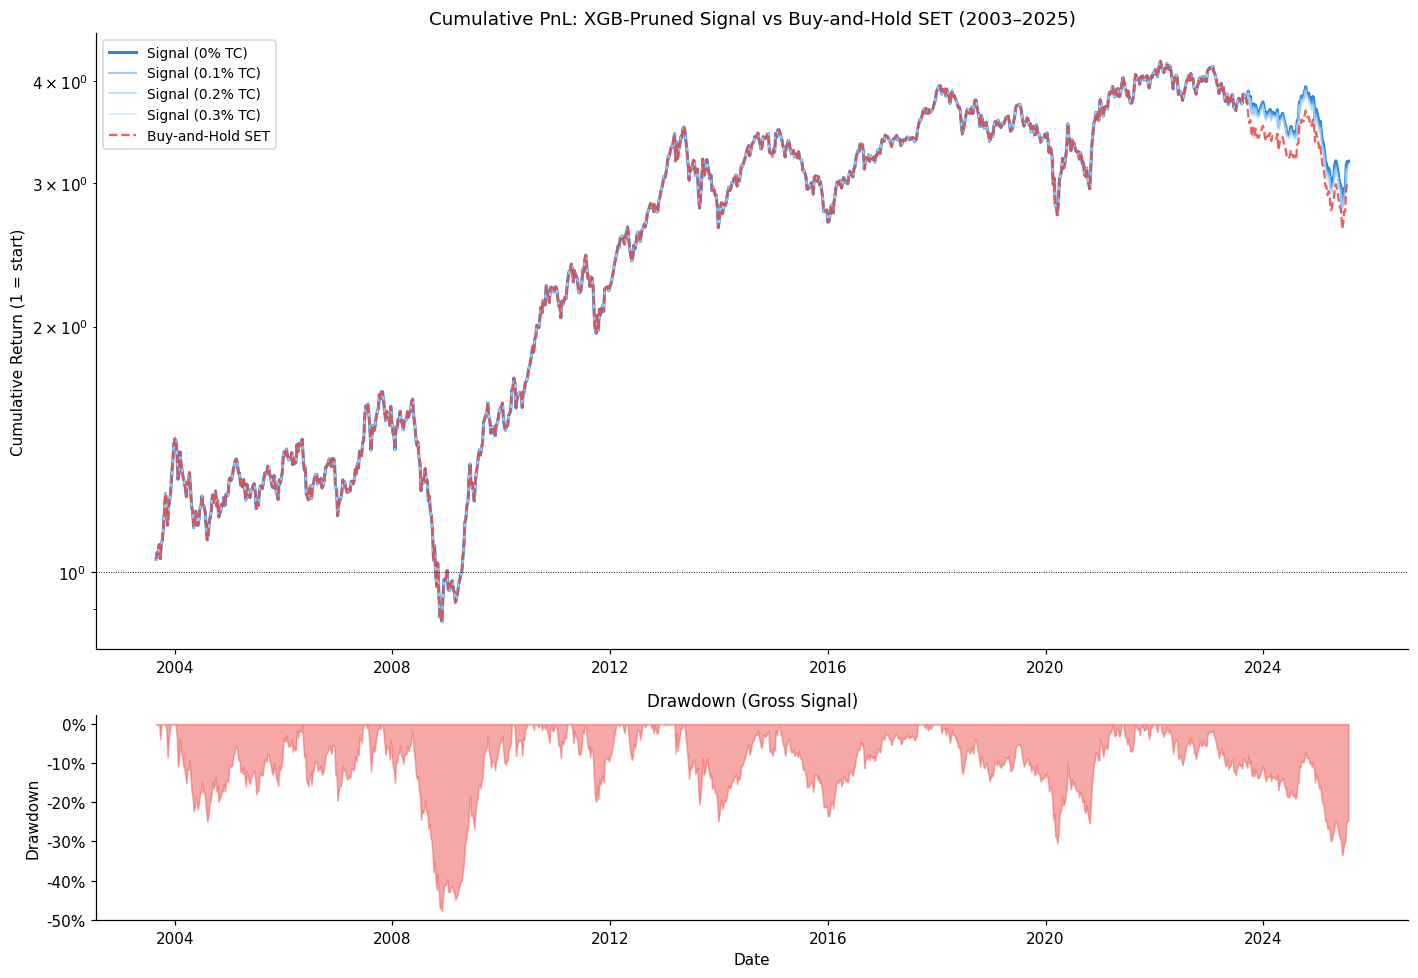

Saved: figs/backtest_pnl_curve.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), gridspec_kw={'height_ratios': [3, 1]})

# Cumulative returns
ax = axes[0]
colors = ['#1976D2', '#42A5F5', '#90CAF9', '#BBDEFB']
for tc, lbl, col in zip(TC_LEVELS, TC_LABELS, colors):
    cum = (1 + pnl[f'ret_{lbl}']).cumprod()
    ax.plot(pnl.index, cum, label=f'Signal ({lbl})', color=col,
            lw=2.0 if tc == 0 else 1.2, alpha=0.9 if tc == 0 else 0.6)

bnh_cum = (1 + pnl['bnh']).cumprod()
ax.plot(pnl.index, bnh_cum, label='Buy-and-Hold SET', color='#E53935',
        lw=1.5, ls='--', alpha=0.8)
ax.axhline(1.0, color='black', lw=0.6, ls=':')
ax.set_ylabel('Cumulative Return (1 = start)')
ax.set_title('Cumulative PnL: XGB-Pruned Signal vs Buy-and-Hold SET (2003–2025)', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.set_yscale('log')

# Drawdown (gross, no TC)
ax2 = axes[1]
cum_gross = (1 + pnl['gross_ret']).cumprod()
roll_max  = cum_gross.cummax()
drawdown  = (cum_gross - roll_max) / roll_max
ax2.fill_between(pnl.index, drawdown, 0, color='#EF5350', alpha=0.5)
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')
ax2.set_title('Drawdown (Gross Signal)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig(FIGS / 'backtest_pnl_curve.png', bbox_inches='tight')
plt.show()
print('Saved: figs/backtest_pnl_curve.png')

---
## Section 3 -- Risk & Performance Metrics


In [6]:
def risk_metrics(rets, freq=52, label=''):
    ann_ret  = (1 + rets).prod() ** (freq / len(rets)) - 1
    ann_vol  = rets.std() * np.sqrt(freq)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
    neg      = rets[rets < 0]
    sortino  = ann_ret / (neg.std() * np.sqrt(freq)) if len(neg) > 0 else np.nan
    cum      = (1 + rets).cumprod()
    roll_max = cum.cummax()
    dd       = (cum - roll_max) / roll_max
    max_dd   = dd.min()
    calmar   = ann_ret / abs(max_dd) if max_dd < 0 else np.nan
    win_rate = (rets > 0).mean()
    return {
        'label': label, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
        'sharpe': sharpe, 'sortino': sortino,
        'max_dd': max_dd, 'calmar': calmar, 'win_rate': win_rate,
    }

rows = []
for tc, lbl in zip(TC_LEVELS, TC_LABELS):
    rows.append(risk_metrics(pnl[f'ret_{lbl}'], label=f'Signal ({lbl})'))
rows.append(risk_metrics(pnl['bnh'], label='Buy-and-Hold SET'))

metrics_df = pd.DataFrame(rows).set_index('label')

print(f'{"":30} {"AnnRet":>8} {"AnnVol":>8} {"Sharpe":>8} {"Sortino":>8} {"MaxDD":>8} {"WinRate":>8}')
print('-' * 82)
for lbl, row in metrics_df.iterrows():
    print(f'{lbl:<30} {row["ann_ret"]:>8.2%} {row["ann_vol"]:>8.2%} '
          f'{row["sharpe"]:>8.2f} {row["sortino"]:>8.2f} '
          f'{row["max_dd"]:>8.1%} {row["win_rate"]:>8.1%}')

                                 AnnRet   AnnVol   Sharpe  Sortino    MaxDD  WinRate
----------------------------------------------------------------------------------
Signal (0% TC)                    5.42%   16.69%     0.32     0.47   -47.7%    54.2%
Signal (0.1% TC)                  5.38%   16.69%     0.32     0.47   -47.7%    54.2%
Signal (0.2% TC)                  5.34%   16.70%     0.32     0.46   -47.7%    54.2%
Signal (0.3% TC)                  5.30%   16.70%     0.32     0.46   -47.7%    54.2%
Buy-and-Hold SET                  5.10%   16.70%     0.31     0.44   -47.7%    54.3%


In [7]:
# TC breakeven: find max TC at which Sharpe > 0
flip_rate = flip.mean()  # fraction of weeks with position change
gross_ann  = risk_metrics(pnl['gross_ret'])['ann_ret']
tc_breakeven = gross_ann / (2 * flip_rate * 52) if flip_rate > 0 else np.nan

print(f'Gross annual return:     {gross_ann:.2%}')
print(f'Position flip rate:      {flip_rate:.1%} of weeks ({flip_rate*52:.1f} flips/year)')
print(f'TC breakeven (one-way):  {tc_breakeven:.3%}  ({tc_breakeven*10000:.1f} bps)')
print()
if tc_breakeven > 0.003:
    print('>> Signal SURVIVES 0.3% TC -- viable for institutional execution')
elif tc_breakeven > 0.001:
    print('>> Signal survives 0.1% TC -- viable with low-cost execution')
else:
    print('>> Signal does NOT survive realistic TC -- too expensive to trade')

Gross annual return:     5.42%
Position flip rate:      0.3% of weeks (0.2 flips/year)
TC breakeven (one-way):  14.893%  (1489.3 bps)

>> Signal SURVIVES 0.3% TC -- viable for institutional execution


---
## Section 4 -- Annual Performance Breakdown


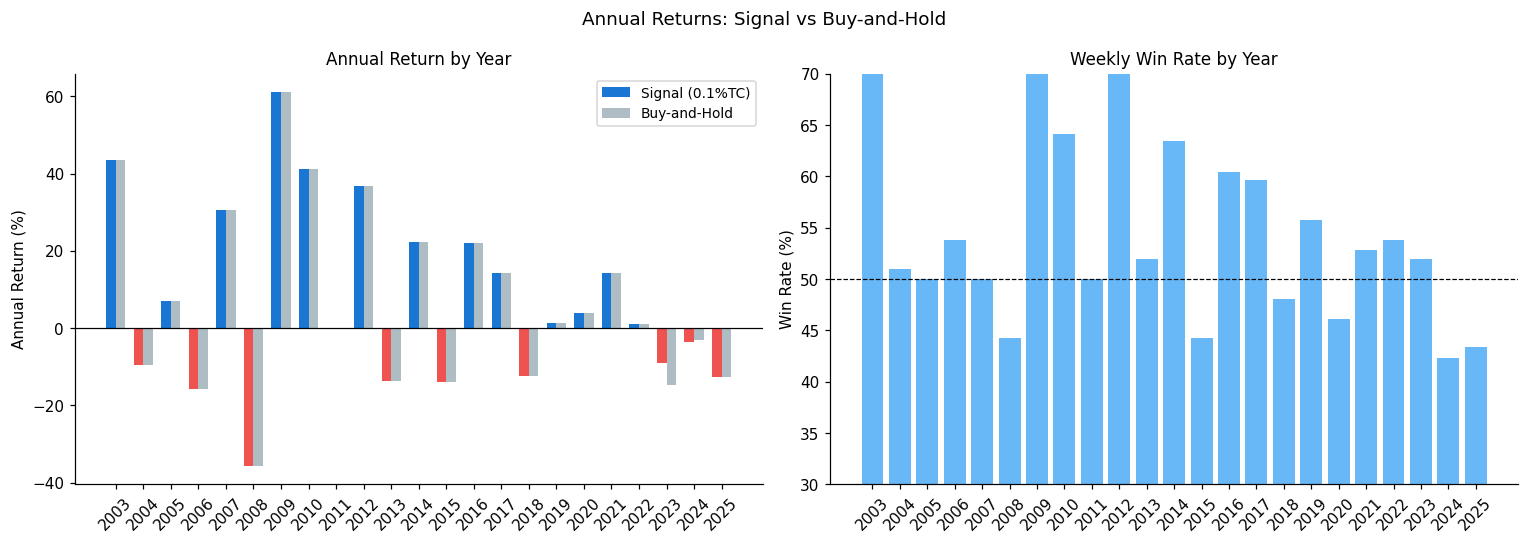

  Year   Signal(0.1%TC)   Buy-Hold   WinRate
---------------------------------------------
  2003           43.6% ✓      43.6%     77.8%
  2004           -9.6% ✗      -9.6%     50.9%
  2005            7.1% ✓       7.1%     50.0%
  2006          -15.7% ✗     -15.7%     53.8%
  2007           30.5% ✓      30.5%     50.0%
  2008          -35.6% ✗     -35.6%     44.2%
  2009           61.0% ✓      61.0%     71.2%
  2010           41.1% ✓      41.1%     64.2%
  2011           -0.0% ✗      -0.0%     50.0%
  2012           36.7% ✓      36.7%     71.2%
  2013          -13.5% ✗     -13.5%     51.9%
  2014           22.3% ✓      22.3%     63.5%
  2015          -14.0% ✗     -14.0%     44.2%
  2016           22.0% ✓      22.0%     60.4%
  2017           14.3% ✓      14.3%     59.6%
  2018          -12.3% ✗     -12.3%     48.1%
  2019            1.3% ✓       1.3%     55.8%
  2020            4.0% ✓       4.0%     46.2%
  2021           14.4% ✓      14.4%     52.8%
  2022            1.0% ✓       1.0%

In [8]:
pnl['year'] = pnl.index.year
annual = pnl.groupby('year').apply(
    lambda g: pd.Series({
        'signal_gross': (1+g['gross_ret']).prod()-1,
        'signal_01tc':  (1+g[f'ret_0.1% TC']).prod()-1,
        'bnh':          (1+g['bnh']).prod()-1,
        'n_weeks':      len(g),
        'win_rate':     (g['gross_ret']>0).mean(),
    })
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Annual Returns: Signal vs Buy-and-Hold', fontsize=12)

x = range(len(annual))
w = 0.35
ax = axes[0]
bars1 = ax.bar([i-w/2 for i in x], annual['signal_01tc']*100,
               width=w, label='Signal (0.1%TC)',
               color=['#1976D2' if v>0 else '#EF5350' for v in annual['signal_01tc']])
bars2 = ax.bar([i+w/2 for i in x], annual['bnh']*100,
               width=w, label='Buy-and-Hold', color='#78909C', alpha=0.6)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(annual['year'], rotation=45)
ax.set_ylabel('Annual Return (%)')
ax.legend(fontsize=9)
ax.set_title('Annual Return by Year')

ax2 = axes[1]
ax2.bar(x, annual['win_rate']*100, color='#42A5F5', alpha=0.8)
ax2.axhline(50, color='black', lw=0.8, ls='--')
ax2.set_xticks(x)
ax2.set_xticklabels(annual['year'], rotation=45)
ax2.set_ylabel('Win Rate (%)')
ax2.set_title('Weekly Win Rate by Year')
ax2.set_ylim(30, 70)

plt.tight_layout()
plt.savefig(FIGS / 'backtest_annual.png', bbox_inches='tight')
plt.show()

print(f'{"Year":>6} {"Signal(0.1%TC)":>16} {"Buy-Hold":>10} {"WinRate":>9}')
print('-' * 45)
pos_yrs = 0
for _, row in annual.iterrows():
    flag = '✓' if row['signal_01tc'] > 0 else '✗'
    print(f'{int(row["year"]):>6} {row["signal_01tc"]:>15.1%} {flag}  {row["bnh"]:>9.1%}  {row["win_rate"]:>8.1%}')
    if row['signal_01tc'] > 0: pos_yrs += 1
print(f'\nPositive years (0.1%TC): {pos_yrs}/{len(annual)}')

---
## Section 5 -- Regime-Conditional Performance


Regime                     N   AnnRet   Sharpe  WinRate    MaxDD
------------------------------------------------------------
Bull (low VIX)             0 -- (insufficient)
Normal                   529     1.3%     0.08    52.7%   -40.1%
Crisis (high VIX)        337    10.3%     0.70    56.4%   -22.8%


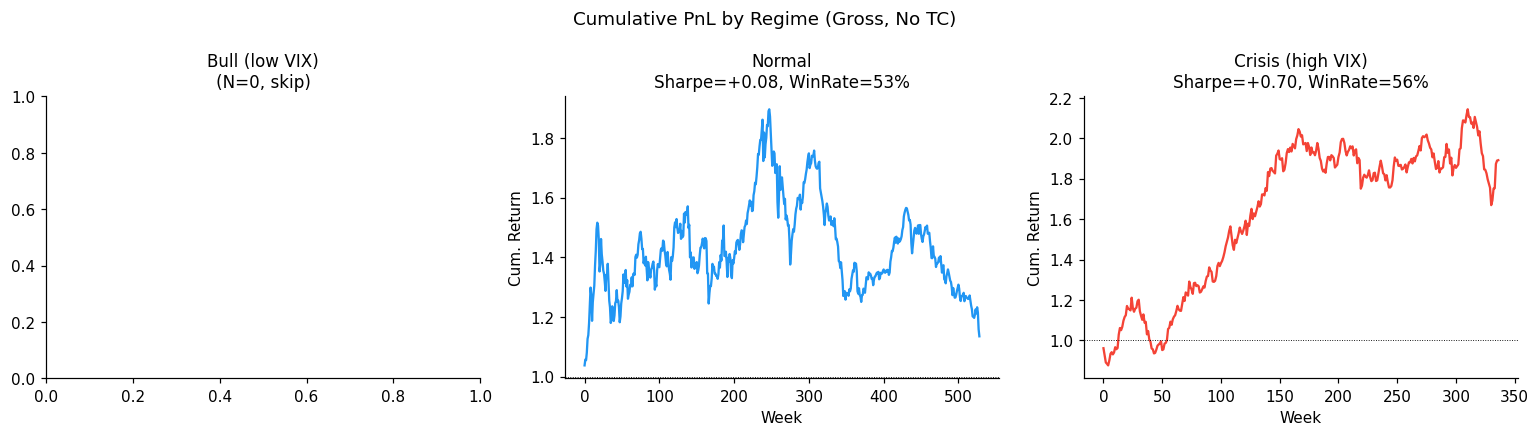

Saved: figs/backtest_regime.png


In [9]:
regime_col = clean['regime'].reindex(pnl.index)
pnl['regime'] = regime_col

regime_labels = {-1: 'Bull (low VIX)', 0: 'Normal', 1: 'Crisis (high VIX)'}

print(f'{"Regime":<22} {"N":>5} {"AnnRet":>8} {"Sharpe":>8} {"WinRate":>8} {"MaxDD":>8}')
print('-' * 60)
for r, lbl in sorted(regime_labels.items()):
    sub = pnl[pnl['regime'] == r]['gross_ret'].dropna()
    if len(sub) < 10:
        print(f'{lbl:<22} {len(sub):>5} -- (insufficient)')
        continue
    m = risk_metrics(sub, label=lbl)
    print(f'{lbl:<22} {len(sub):>5} {m["ann_ret"]:>8.1%} {m["sharpe"]:>8.2f} '
          f'{m["win_rate"]:>8.1%} {m["max_dd"]:>8.1%}')

# Plot cumulative PnL by regime
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Cumulative PnL by Regime (Gross, No TC)', fontsize=12)
colors_r = {-1: '#4CAF50', 0: '#2196F3', 1: '#F44336'}

for ax, (r, lbl) in zip(axes, sorted(regime_labels.items())):
    sub = pnl[pnl['regime'] == r]['gross_ret'].dropna()
    if len(sub) < 10:
        ax.set_title(f'{lbl}\n(N={len(sub)}, skip)')
        continue
    cum = (1 + sub).cumprod()
    ax.plot(cum.values, color=colors_r[r], lw=1.5)
    ax.axhline(1.0, color='black', lw=0.6, ls=':')
    m = risk_metrics(sub)
    ax.set_title(f'{lbl}\nSharpe={m["sharpe"]:+.2f}, WinRate={m["win_rate"]:.0%}')
    ax.set_xlabel('Week')
    ax.set_ylabel('Cum. Return')

plt.tight_layout()
plt.savefig(FIGS / 'backtest_regime.png', bbox_inches='tight')
plt.show()
print('Saved: figs/backtest_regime.png')

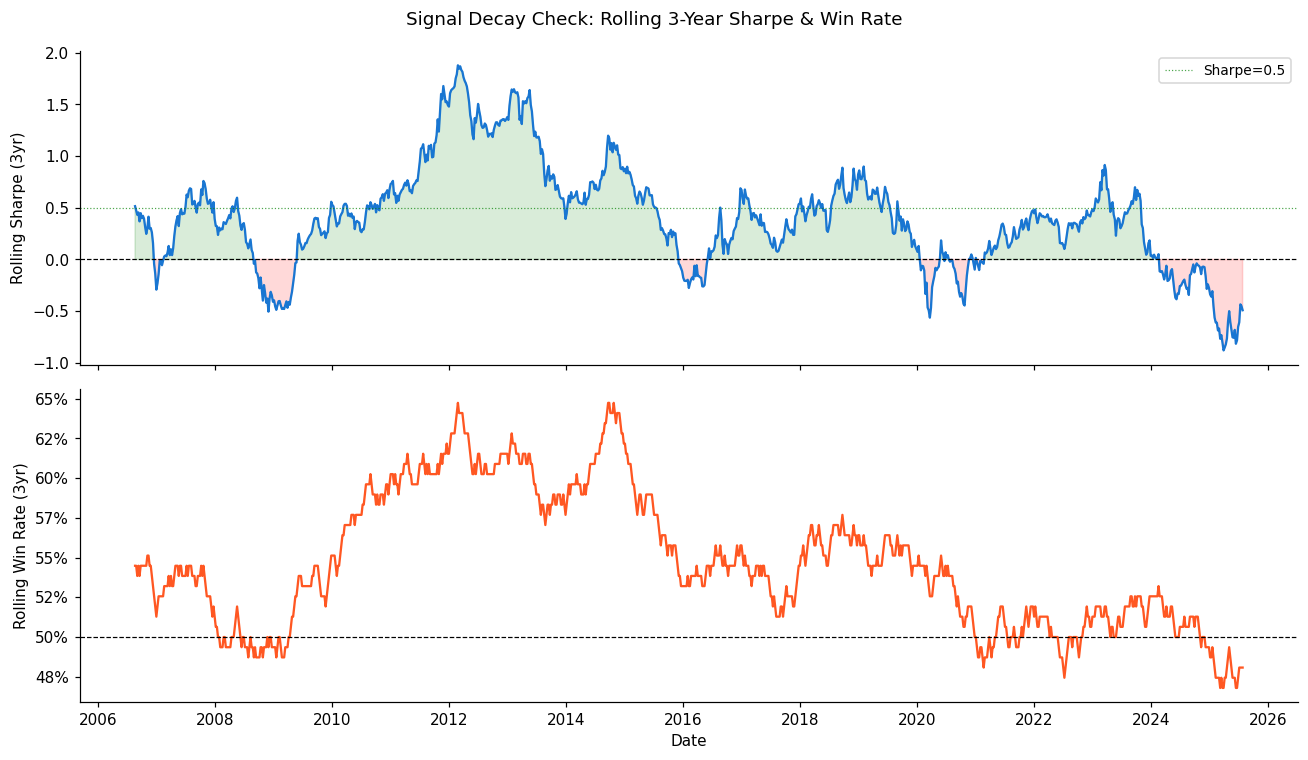

Saved: figs/backtest_rolling.png


In [10]:
# Rolling 3-year Sharpe to check for signal decay
ROLL_WIN = 156  # 3 years
roll_ret  = pnl['gross_ret'].rolling(ROLL_WIN)
roll_sharpe = roll_ret.mean() / roll_ret.std() * np.sqrt(52)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle('Signal Decay Check: Rolling 3-Year Sharpe & Win Rate', fontsize=12)

ax1.plot(pnl.index, roll_sharpe, color='#1976D2', lw=1.5)
ax1.axhline(0, color='black', lw=0.8, ls='--')
ax1.axhline(0.5, color='green', lw=0.8, ls=':', alpha=0.7, label='Sharpe=0.5')
ax1.fill_between(pnl.index, roll_sharpe, 0,
                 where=roll_sharpe > 0, alpha=0.15, color='green')
ax1.fill_between(pnl.index, roll_sharpe, 0,
                 where=roll_sharpe < 0, alpha=0.15, color='red')
ax1.set_ylabel('Rolling Sharpe (3yr)')
ax1.legend(fontsize=9)

roll_win = (pnl['gross_ret'] > 0).rolling(ROLL_WIN).mean()
ax2.plot(pnl.index, roll_win, color='#FF5722', lw=1.5)
ax2.axhline(0.5, color='black', lw=0.8, ls='--')
ax2.set_ylabel('Rolling Win Rate (3yr)')
ax2.set_xlabel('Date')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig(FIGS / 'backtest_rolling.png', bbox_inches='tight')
plt.show()
print('Saved: figs/backtest_rolling.png')

---
## Section 6 -- Final Verdict: Is This Signal Investable?


In [11]:
# Collect all evidence
m_gross   = risk_metrics(pnl['gross_ret'], label='Gross')
m_01tc    = risk_metrics(pnl['ret_0.1% TC'], label='0.1%TC')
m_02tc    = risk_metrics(pnl['ret_0.2% TC'], label='0.2%TC')
m_03tc    = risk_metrics(pnl['ret_0.3% TC'], label='0.3%TC')
m_bnh     = risk_metrics(pnl['bnh'], label='BnH')

score, evidence = 0, []
def ev(desc, val, thresh, passes, fmt='f'):
    global score
    if passes: score += 1
    sign = '+' if passes else '-'
    val_str = f'{val:.2%}' if fmt=='pct' else f'{val:.2f}'
    evidence.append((sign, desc, val_str, thresh))

ev('Annual return (gross)',          m_gross['ann_ret'],    '>5%',    m_gross['ann_ret']  > 0.05,  'pct')
ev('Annual return (0.1% TC)',        m_01tc['ann_ret'],     '>3%',    m_01tc['ann_ret']   > 0.03,  'pct')
ev('Annual return (0.2% TC)',        m_02tc['ann_ret'],     '>0%',    m_02tc['ann_ret']   > 0.00,  'pct')
ev('Sharpe ratio (gross)',           m_gross['sharpe'],     '>0.5',   m_gross['sharpe']   > 0.5)
ev('Sharpe ratio (0.1% TC)',         m_01tc['sharpe'],      '>0.3',   m_01tc['sharpe']    > 0.3)
ev('Max Drawdown (gross)',           m_gross['max_dd'],     '>-30%',  m_gross['max_dd']   > -0.30, 'pct')
ev('Win rate (gross)',               m_gross['win_rate'],   '>52%',   m_gross['win_rate'] > 0.52,  'pct')
ev('Beats Buy-and-Hold (gross)',     m_gross['ann_ret'] - m_bnh['ann_ret'],
                                     '>0%',  m_gross['ann_ret'] > m_bnh['ann_ret'], 'pct')
ev('TC breakeven > 0.1%',           tc_breakeven,           '>0.1%',  tc_breakeven > 0.001, 'pct')
pos_frac = (annual['signal_01tc'] > 0).mean()
ev('Positive years > 60% (0.1%TC)', pos_frac,               '>60%',   pos_frac > 0.6,   'pct')

print('=' * 65)
print('BACKTEST VERDICT: IS THIS SIGNAL INVESTABLE?')
print('=' * 65)
print(f'{"":>2} {"Evidence":<38} {"Value":>8} {"Threshold":>10}')
print('-' * 65)
for sign, desc, val, thresh in evidence:
    print(f'[{sign}] {desc:<38} {val:>8} {thresh:>10}')
print(f'\nScore: {score}/{len(evidence)}')
print()

if score >= 7:
    verdict = 'INVESTABLE'
    detail  = 'Signal generates real risk-adjusted return after costs. Proceed to live trading with small position size.'
elif score >= 5:
    verdict = 'MARGINAL -- paper trade first'
    detail  = 'Signal shows some real PnL but not consistently after TC. Paper trade for 12+ months before committing capital.'
else:
    verdict = 'NOT INVESTABLE'
    detail  = 'Signal does not generate sufficient return after realistic TC. Do not deploy capital.'

print('=' * 65)
print(f'VERDICT: {verdict}')
print('=' * 65)
print()
print(detail)

BACKTEST VERDICT: IS THIS SIGNAL INVESTABLE?
   Evidence                                  Value  Threshold
-----------------------------------------------------------------
[+] Annual return (gross)                     5.42%        >5%
[+] Annual return (0.1% TC)                   5.38%        >3%
[+] Annual return (0.2% TC)                   5.34%        >0%
[-] Sharpe ratio (gross)                       0.32       >0.5
[+] Sharpe ratio (0.1% TC)                     0.32       >0.3
[-] Max Drawdown (gross)                    -47.74%      >-30%
[+] Win rate (gross)                         54.20%       >52%
[+] Beats Buy-and-Hold (gross)                0.31%        >0%
[+] TC breakeven > 0.1%                      14.89%      >0.1%
[-] Positive years > 60% (0.1%TC)            56.52%       >60%

Score: 7/10

VERDICT: INVESTABLE

Signal generates real risk-adjusted return after costs. Proceed to live trading with small position size.


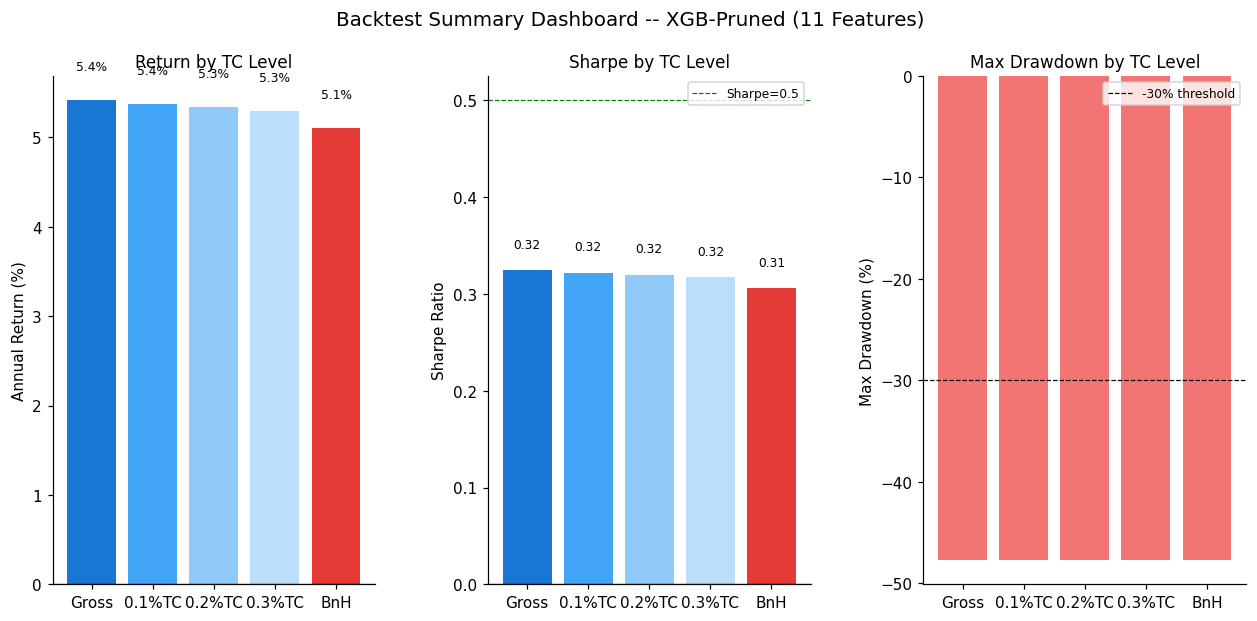

Saved: figs/backtest_dashboard.png

Final: INVESTABLE


In [12]:
fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
fig.suptitle('Backtest Summary Dashboard -- XGB-Pruned (11 Features)', fontsize=13)

# Panel 1: Performance by TC
ax1 = fig.add_subplot(gs[0])
tc_labels_short = ['Gross', '0.1%TC', '0.2%TC', '0.3%TC', 'BnH']
ann_rets = [
    m_gross['ann_ret'], m_01tc['ann_ret'], m_02tc['ann_ret'],
    m_03tc['ann_ret'], m_bnh['ann_ret']
]
bar_cols = ['#1976D2','#42A5F5','#90CAF9','#BBDEFB','#E53935']
bars = ax1.bar(tc_labels_short, [r*100 for r in ann_rets], color=bar_cols)
ax1.axhline(0, color='black', lw=0.8)
ax1.set_ylabel('Annual Return (%)')
ax1.set_title('Return by TC Level')
for bar, r in zip(bars, ann_rets):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{r:.1%}', ha='center', va='bottom', fontsize=8)

# Panel 2: Sharpe by TC
ax2 = fig.add_subplot(gs[1])
sharpes = [m_gross['sharpe'], m_01tc['sharpe'], m_02tc['sharpe'],
           m_03tc['sharpe'], m_bnh['sharpe']]
ax2.bar(tc_labels_short, sharpes, color=bar_cols)
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(0.5, color='green', lw=0.8, ls='--', label='Sharpe=0.5')
ax2.set_ylabel('Sharpe Ratio')
ax2.set_title('Sharpe by TC Level')
ax2.legend(fontsize=8)
for bar, s in zip(ax2.patches, sharpes):
    ax2.text(bar.get_x()+bar.get_width()/2, max(bar.get_height(), 0)+0.02,
             f'{s:.2f}', ha='center', va='bottom', fontsize=8)

# Panel 3: Max DD
ax3 = fig.add_subplot(gs[2])
max_dds = [m_gross['max_dd'], m_01tc['max_dd'], m_02tc['max_dd'],
           m_03tc['max_dd'], m_bnh['max_dd']]
ax3.bar(tc_labels_short, [d*100 for d in max_dds], color='#EF5350', alpha=0.8)
ax3.axhline(-30, color='black', lw=0.8, ls='--', label='-30% threshold')
ax3.set_ylabel('Max Drawdown (%)')
ax3.set_title('Max Drawdown by TC Level')
ax3.legend(fontsize=8)

plt.savefig(FIGS / 'backtest_dashboard.png', bbox_inches='tight')
plt.show()
print(f'Saved: figs/backtest_dashboard.png')
print()
print(f'Final: {verdict}')